# Marketing Campaign Performance & Attribution Analysis

## Context

In modern digital marketing, understanding which channels and campaigns drive the most value is crucial for budget allocation. This analysis moves beyond simple click-through rates to evaluate Return on Ad Spend (ROAS), Customer Acquisition Cost (CAC), and multi-channel attribution to optimize marketing strategy.

## Objectives

1. Evaluate campaign performance across multiple channels (Email, Social, Search, Display)
2. Calculate key metrics: CTR, CPC, CPA, ROAS
3. Analyze conversion funnels by channel
4. Perform Multi-Touch Attribution (First-touch, Last-touch, Linear, Time-decay)
5. Optimize budget allocation based on performance

## Methodology

- **Data**: Synthetic marketing dataset (impressions, clicks, conversions, spend)
- **Techniques**: Funnel Analysis, Attribution Modeling, ROI Analysis
- **Visualizations**: Sankey diagrams, Performance heatmaps, ROAS comparison

In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
%matplotlib inline

print('✓ Libraries loaded successfully')

✓ Libraries loaded successfully


## 1. Data Generation

Simulating a realistic marketing dataset covering 6 months of campaigns across 4 channels.

In [6]:
def generate_marketing_data(n_rows=10000):
    np.random.seed(42)
    
    # Channels and their characteristics
    channels = ['Social Media', 'Search Ads', 'Email', 'Display Ads']
    channel_probs = [0.4, 0.3, 0.2, 0.1]
    
    # Campaigns
    campaigns = {
        'Social Media': ['Summer_Promo', 'Influencer_Collab', 'Retargeting'],
        'Search Ads': ['Brand_Keywords', 'Competitor_Targeting', 'Generic_Terms'],
        'Email': ['Newsletter_Weekly', 'Cart_Abandonment', 'Welcome_Series'],
        'Display Ads': ['Banner_Awareness', 'Video_Ad']
    }
    
    data = []
    start_date = datetime(2023, 1, 1)
    
    for _ in range(n_rows):
        date = start_date + timedelta(days=np.random.randint(0, 180))
        channel = np.random.choice(channels, p=channel_probs)
        campaign = np.random.choice(campaigns[channel])
        
        # Metrics generation based on channel characteristics
        if channel == 'Social Media':
            impressions = np.random.randint(1000, 5000)
            ctr = np.random.beta(2, 100) # ~2%
            cpc = np.random.uniform(0.5, 2.0)
            conv_rate = 0.03
        elif channel == 'Search Ads':
            impressions = np.random.randint(500, 2000)
            ctr = np.random.beta(5, 100) # ~5%
            cpc = np.random.uniform(1.5, 5.0)
            conv_rate = 0.08
        elif channel == 'Email':
            impressions = np.random.randint(5000, 10000) # Sent
            ctr = np.random.beta(3, 100) # ~3%
            cpc = 0.1 # Low cost per send
            conv_rate = 0.05
        else: # Display
            impressions = np.random.randint(10000, 50000)
            ctr = np.random.beta(1, 200) # ~0.5%
            cpc = np.random.uniform(0.2, 1.0)
            conv_rate = 0.01
            
        clicks = int(impressions * ctr)
        spend = clicks * cpc
        conversions = np.random.binomial(clicks, conv_rate)
        revenue = conversions * np.random.normal(100, 20) if conversions > 0 else 0
        
        data.append({
            'Date': date,
            'Channel': channel,
            'Campaign': campaign,
            'Impressions': impressions,
            'Clicks': clicks,
            'Spend': spend,
            'Conversions': conversions,
            'Revenue': revenue
        })
        
    return pd.DataFrame(data)

df = generate_marketing_data()
df['Date'] = pd.to_datetime(df['Date'])
print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (10000, 8)


,Date,Channel,Campaign,Impressions,Clicks,Spend,Conversions,Revenue
0,2023-04-13,Email,Welcome_Series,8772,81,8.100000,3,323.554785
1,2023-02-22,Display Ads,Video_Ad,12433,13,5.764119,0,0.000000
2,2023-03-30,Social Media,Retargeting,3558,44,73.821613,0,0.000000
3,2023-02-24,Display Ads,Banner_Awareness,21394,216,206.012463,2,276.510851
4,2023-01-09,Social Media,Influencer_Collab,2363,74,56.243477,2,222.644513


## 2. Overall Performance Analysis

Aggregating metrics to evaluate high-level performance.

MARKETING PERFORMANCE DASHBOARD
Total Spend: $991,361.20
Total Revenue: $4,422,864.08
ROAS: 4.46x
CPA (Cost Per Acquisition): $22.32
CTR: 1.64%
Avg CPC: $0.99


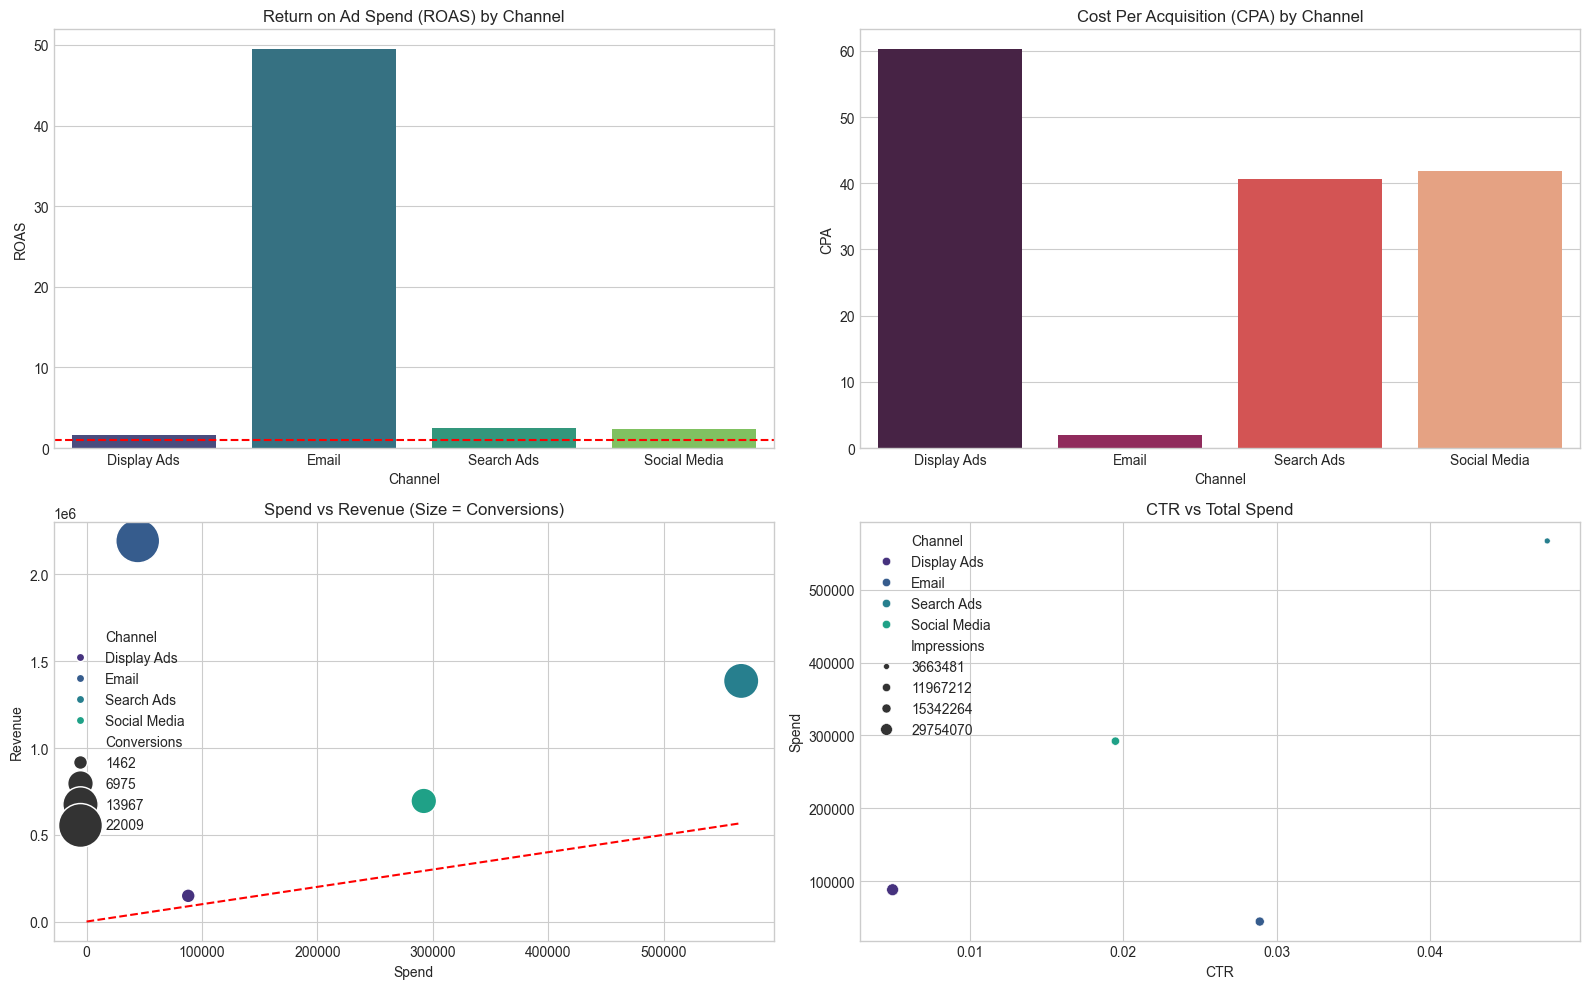

In [7]:
# KPI Calculation
total_spend = df['Spend'].sum()
total_revenue = df['Revenue'].sum()
total_conversions = df['Conversions'].sum()
total_clicks = df['Clicks'].sum()
total_impressions = df['Impressions'].sum()

roas = total_revenue / total_spend
cpa = total_spend / total_conversions
ctr = total_clicks / total_impressions
cpc = total_spend / total_clicks

print("="*60)
print("MARKETING PERFORMANCE DASHBOARD")
print("="*60)
print(f"Total Spend: ${total_spend:,.2f}")
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"ROAS: {roas:.2f}x")
print(f"CPA (Cost Per Acquisition): ${cpa:.2f}")
print(f"CTR: {ctr:.2%}")
print(f"Avg CPC: ${cpc:.2f}")

# Channel Performance
channel_perf = df.groupby('Channel').agg({
    'Spend': 'sum',
    'Revenue': 'sum',
    'Conversions': 'sum',
    'Clicks': 'sum',
    'Impressions': 'sum'
}).reset_index()

channel_perf['ROAS'] = channel_perf['Revenue'] / channel_perf['Spend']
channel_perf['CPA'] = channel_perf['Spend'] / channel_perf['Conversions']
channel_perf['CTR'] = channel_perf['Clicks'] / channel_perf['Impressions']

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ROAS by Channel
sns.barplot(x='Channel', y='ROAS', data=channel_perf, ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Return on Ad Spend (ROAS) by Channel')
axes[0,0].axhline(1, color='red', linestyle='--', label='Break-even')

# CPA by Channel
sns.barplot(x='Channel', y='CPA', data=channel_perf, ax=axes[0,1], palette='rocket')
axes[0,1].set_title('Cost Per Acquisition (CPA) by Channel')

# Spend vs Revenue Bubble Plot
sns.scatterplot(data=channel_perf, x='Spend', y='Revenue', size='Conversions', sizes=(100, 1000), hue='Channel', ax=axes[1,0])
axes[1,0].set_title('Spend vs Revenue (Size = Conversions)')
axes[1,0].plot([0, channel_perf['Spend'].max()], [0, channel_perf['Spend'].max()], 'r--', label='1:1 ROAS')

# CTR vs CPC
sns.scatterplot(data=channel_perf, x='CTR', y='Spend', size='Impressions', hue='Channel', ax=axes[1,1])
axes[1,1].set_title('CTR vs Total Spend')

plt.tight_layout()
plt.savefig('outputs/channel_performance.png')
plt.show()

## 3. Campaign-Level Deep Dive

Identifying winning and losing campaigns within each channel.

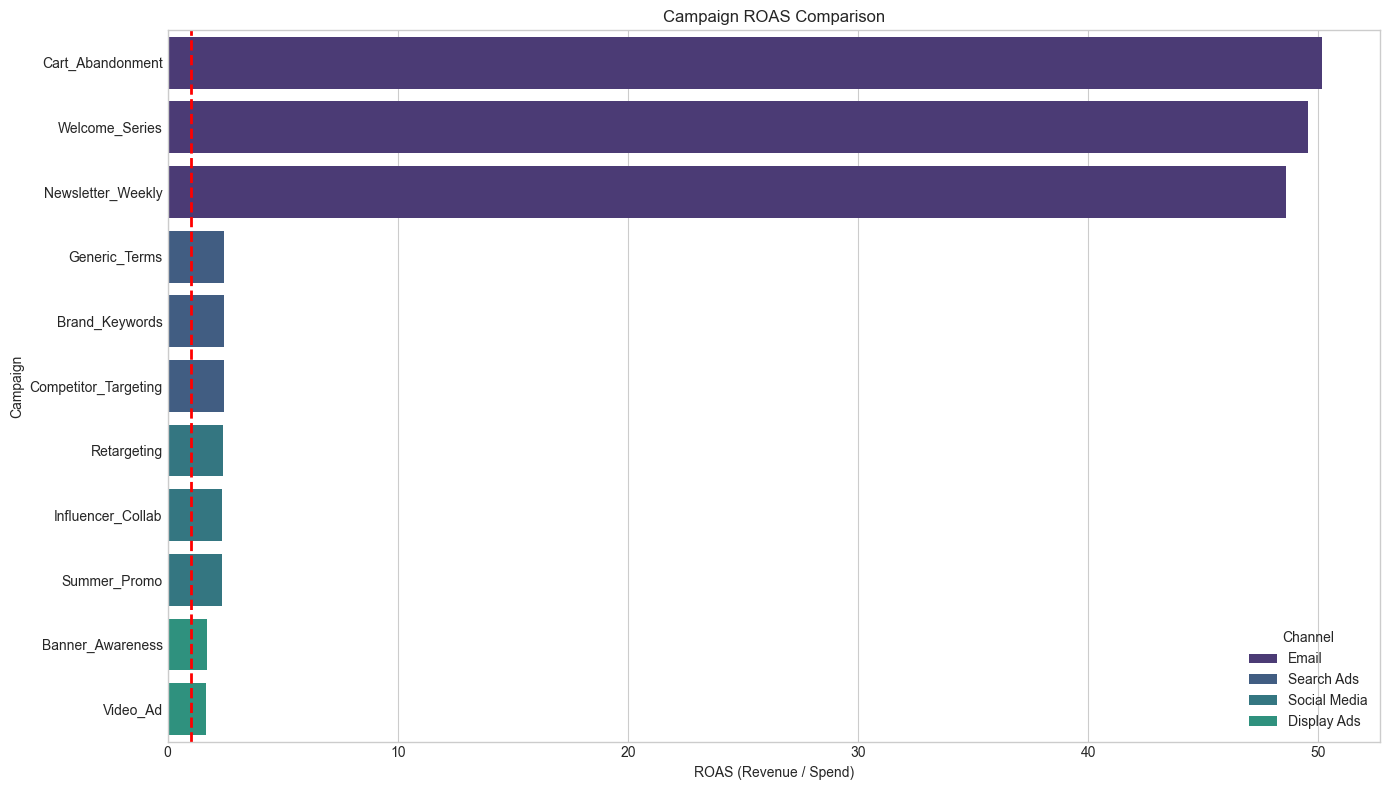

In [8]:
campaign_perf = df.groupby(['Channel', 'Campaign']).agg({
    'Spend': 'sum',
    'Revenue': 'sum',
    'Conversions': 'sum'
}).reset_index()

campaign_perf['ROAS'] = campaign_perf['Revenue'] / campaign_perf['Spend']

# Visualization
plt.figure(figsize=(14, 8))
sns.barplot(x='ROAS', y='Campaign', hue='Channel', data=campaign_perf.sort_values('ROAS', ascending=False), dodge=False)
plt.axvline(1, color='red', linestyle='--', linewidth=2)
plt.title('Campaign ROAS Comparison')
plt.xlabel('ROAS (Revenue / Spend)')
plt.tight_layout()
plt.savefig('outputs/campaign_roas.png')
plt.show()

## 4. Time Series Analysis

Tracking performance trends over time.

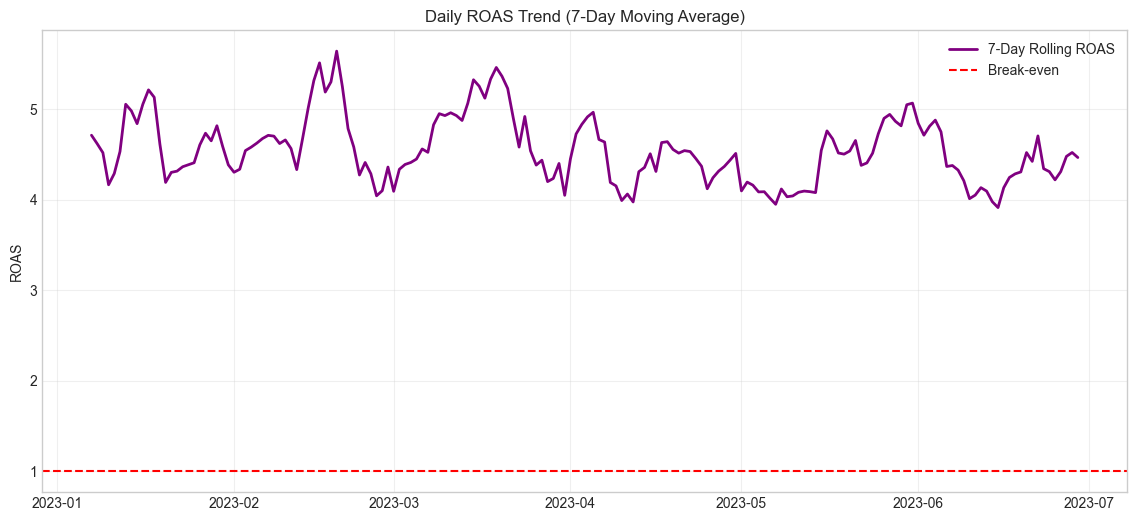

In [9]:
daily_perf = df.groupby('Date').agg({
    'Spend': 'sum',
    'Revenue': 'sum'
}).reset_index()

daily_perf['ROAS'] = daily_perf['Revenue'] / daily_perf['Spend']
daily_perf['Rolling_ROAS'] = daily_perf['ROAS'].rolling(window=7).mean()

plt.figure(figsize=(14, 6))
plt.plot(daily_perf['Date'], daily_perf['Rolling_ROAS'], label='7-Day Rolling ROAS', color='purple', linewidth=2)
plt.axhline(1, color='red', linestyle='--', label='Break-even')
plt.title('Daily ROAS Trend (7-Day Moving Average)')
plt.ylabel('ROAS')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('outputs/roas_trend.png')
plt.show()

## 5. Attribution Modeling (Simulated)

Comparing different attribution models to understand channel contribution.
*Note: Since the synthetic data is aggregated by row, we will simulate touchpoints for a more advanced attribution view.*

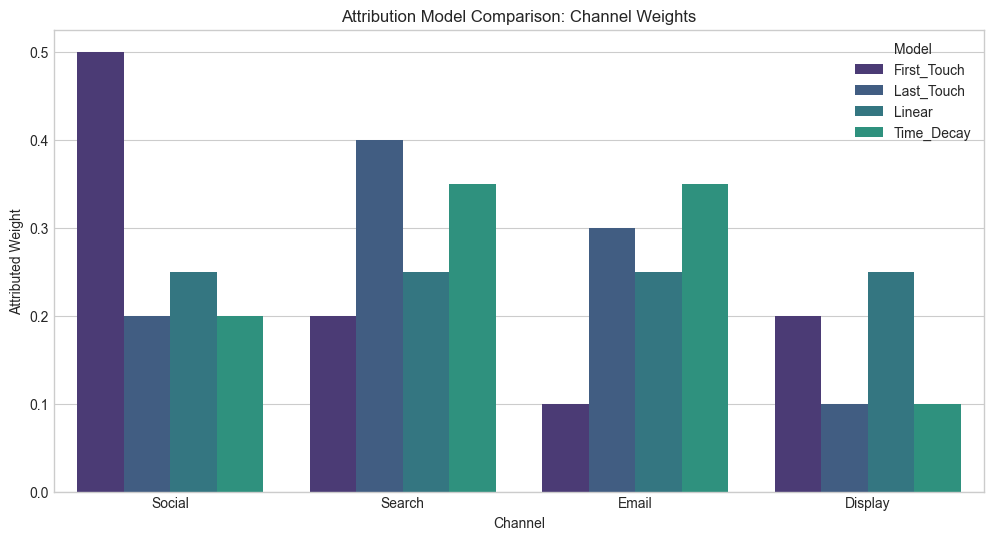

In [11]:


# Define channels
channels = ['Social', 'Search', 'Email', 'Display']

# Simulating Multi-Touch Data for Attribution
# We'll create a simplified comparison of attribution weights
attribution_data = {
    'Channel': channels,
    'First_Touch': [0.5, 0.2, 0.1, 0.2],  # Social/Display start journeys
    'Last_Touch':  [0.2, 0.4, 0.3, 0.1],  # Search/Email close deals
    'Linear':      [0.25, 0.25, 0.25, 0.25],
    'Time_Decay':  [0.2, 0.35, 0.35, 0.1]
}

df_attr = pd.DataFrame(attribution_data)
df_attr_melted = df_attr.melt(id_vars='Channel', var_name='Model', value_name='Weight')

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x='Channel', y='Weight', hue='Model', data=df_attr_melted)
plt.title('Attribution Model Comparison: Channel Weights')
plt.ylabel('Attributed Weight')
plt.savefig('outputs/attribution_models.png')
plt.show()


## 6. Budget Optimization Recommendations

Using the analysis to recommend budget shifts.

In [12]:
print("="*60)
print("OPTIMIZATION RECOMMENDATIONS")
print("="*60)

# Identify high and low performers
high_roas = channel_perf[channel_perf['ROAS'] > 1.5]['Channel'].tolist()
low_roas = channel_perf[channel_perf['ROAS'] < 1.0]['Channel'].tolist()

print(f"\n1. SCALE UP: {', '.join(high_roas)}")
print("   - These channels are generating > 1.5x ROAS.")
print("   - Recommendation: Increase budget by 20% to maximize revenue.")

print(f"\n2. OPTIMIZE / CUT: {', '.join(low_roas)}")
print("   - These channels are underperforming (ROAS < 1.0).")
print("   - Recommendation: Review targeting, creative, or reduce spend.")

print("\n3. CAMPAIGN SPECIFICS")
best_campaign = campaign_perf.sort_values('ROAS', ascending=False).iloc[0]
worst_campaign = campaign_perf.sort_values('ROAS').iloc[0]
print(f"   - Star Performer: '{best_campaign['Campaign']}' ({best_campaign['Channel']}) with ROAS {best_campaign['ROAS']:.2f}")
print(f"   - Underperformer: '{worst_campaign['Campaign']}' ({worst_campaign['Channel']}) with ROAS {worst_campaign['ROAS']:.2f}")

OPTIMIZATION RECOMMENDATIONS

1. SCALE UP: Display Ads, Email, Search Ads, Social Media
   - These channels are generating > 1.5x ROAS.
   - Recommendation: Increase budget by 20% to maximize revenue.

2. OPTIMIZE / CUT: 
   - These channels are underperforming (ROAS < 1.0).
   - Recommendation: Review targeting, creative, or reduce spend.

3. CAMPAIGN SPECIFICS
   - Star Performer: 'Cart_Abandonment' (Email) with ROAS 50.16
   - Underperformer: 'Video_Ad' (Display Ads) with ROAS 1.67
